<a href="https://colab.research.google.com/github/vinifrts/nba-salary-performance-analysis/blob/main/NBA_Analysis_Salary_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Descritiva de Desempenho e Salários na NBA


Equipe analisada: Golden State Warriors  
Temporadas analisadas: 2021 e 2022  

Integrantes do grupo:
Vinícius Freitas - 2422972

João Pedro Muniz - 2413088


TEAM ID DATASET - GS

##Objetivos da equipe

O objetivo deste trabalho é realizar uma analise descritiva dos salários e desempenho dos jogadores da equipe do Golden State Warriors em duas temporadas consecutivas.

Buscamos identificar possíveis padrões e mudanças de perfil da eqiupe entre as temporadas analisadas, considerando e relacionando com o salario indicadores de desempenho como:

- pontos
- assistências
- rebotes
- minutos totais
- custo por minuto
- custo por ponto

A análise será conduzida apenas no nivel descritivo, utilizando tabelas e gráficos para apoiar a interpretação dos dados.

##INFORMAÇOES (APAGAR DEPOIS)

O notebook deverá conter, no mínimo, as seguintes seções:

identificação do grupo, da equipe e das temporadas analisadas;
objetivo da análise;
carregamento e filtragem dos dados;
análise descritiva dos salários;
análise descritiva dos indicadores de desempenho;
análise comparativa entre as duas temporadas;
discussão de valores extremos ou perfis atípicos;
conclusão final.



Instrucoes do professor checkpoint 4:
- criar comparativo minutos x pontos
- criar comparativo custo por minuto
- analisar os que jogam pouco e tirar conclusoes
- criar graficos para analisar outliers (boxplot, etc)
- explorar as variaveis (media, moda, mediana, desvio padrao,




## O que o grupo deve fazer

Analisar a equipe e o par de temporadas designados para o grupo.
Identificar os jogadores registrados em cada temporada.
Descrever o perfil salarial da equipe em cada temporada.
Comparar salários e indicadores de desempenho entre as duas temporadas.
Usar tabelas e gráficos para sustentar a análise.
Discutir jogadores com valores extremos ou perfis atípicos.
Apresentar uma conclusão descritiva baseada nas evidências obtidas.

## CARREGAMENTO DOS DADOS

In [ ]:
# Importação das bibliotecas.
from pathlib import Path
import os
from gdown import download
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#configs dos gráficos
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "STIXGeneral"],
    'figure.figsize': (7, 4.5),
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [ ]:
# Definir a função download_from_drive
def download_from_drive(link,filename):

    # Criar a pasta para download
    foldername = filename.split('/')[0]
    if not os.path.exists(foldername):
        os.makedirs(foldername)
    else:
        print(f'A pasta {foldername} já existe!')

    # Extrair o ID do arquivo a partir do link do Google Drive
    file_id = link.split('/')[5]
    # Criar a URL de download usando o ID do arquivo
    url = f'https://drive.google.com/uc?id={file_id}'
    download(url, filename, quiet = False)

In [ ]:
# Download arquivo CSV e figuras PNG
url_dataset = 'https://drive.google.com/file/d/1WOzabGvTmyTcjWIsDRO0wjrybwLubnyu/view?usp=share_link'
dst_dataset = 'dataset/nba_stats_preprocessed.csv'

download_from_drive(url_dataset,dst_dataset)

Downloading...
From: https://drive.google.com/uc?id=1WOzabGvTmyTcjWIsDRO0wjrybwLubnyu
To: /content/dataset/nba_stats_preprocessed.csv
100%|██████████| 2.44M/2.44M [00:00<00:00, 50.2MB/s]


In [ ]:
# Lê o CSV original e cria uma cópia de trabalho.
df_raw = pd.read_csv("/content/dataset/nba_stats_preprocessed.csv")
df = df_raw.copy()
df.head(10)

,temporada,nome_jogador,id_jogador,id_url_jogador,sigla_posicao,sigla_time,status_jogador,jogos_disputados,faltas_flagrantes,faltas_tecnicas,...,informacoes_recrutamento,local_nascimento,nome_time,ranking_salarial,salario_usd,data_nascimento,idade_temporada,anos_experiencia,altura_m,peso_kg
0,1999,Allen Iverson,366,allen-iverson,SG,PHI,inactive,48.0,0.0,5.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,15,9000000.0,1975-06-07,24.0,NaN,NaN,NaN
1,2000,Allen Iverson,366,allen-iverson,SG,PHI,inactive,70.0,0.0,12.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,27,10125000.0,1975-06-07,25.0,NaN,NaN,NaN
2,2001,Allen Iverson,366,allen-iverson,SG,PHI,inactive,71.0,0.0,18.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,17,11250000.0,1975-06-07,26.0,NaN,NaN,NaN
3,2002,Allen Iverson,366,allen-iverson,SG,PHI,inactive,60.0,0.0,12.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,14,12375000.0,1975-06-07,27.0,NaN,NaN,NaN
4,2003,Allen Iverson,366,allen-iverson,SG,PHI,inactive,82.0,0.0,8.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,11,13500000.0,1975-06-07,28.0,NaN,NaN,NaN
5,2004,Allen Iverson,366,allen-iverson,SG,PHI,inactive,48.0,0.0,7.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,8,14625000.0,1975-06-07,29.0,NaN,NaN,NaN
6,2005,Allen Iverson,366,allen-iverson,SG,PHI,inactive,75.0,0.0,10.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,4,16453125.0,1975-06-07,30.0,NaN,NaN,NaN
7,2006,Allen Iverson,366,allen-iverson,SG,PHI,inactive,72.0,0.0,13.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,7,17184375.0,1975-06-07,31.0,NaN,NaN,NaN
8,2007,Allen Iverson,366,allen-iverson,SG,DEN,inactive,65.0,0.0,12.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,7,19012500.0,1975-06-07,32.0,NaN,NaN,NaN
9,2008,Allen Iverson,366,allen-iverson,SG,DEN,inactive,82.0,0.0,5.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,6,20840625.0,1975-06-07,33.0,NaN,NaN,NaN


## Estrutura do Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8162 entries, 0 to 8161
Data columns (total 42 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   temporada                      8162 non-null   int64  
 1   nome_jogador                   8162 non-null   object 
 2   id_jogador                     8162 non-null   int64  
 3   id_url_jogador                 8162 non-null   object 
 4   sigla_posicao                  8162 non-null   object 
 5   sigla_time                     8162 non-null   object 
 6   status_jogador                 8162 non-null   object 
 7   jogos_disputados               8162 non-null   float64
 8   faltas_flagrantes              8162 non-null   float64
 9   faltas_tecnicas                8162 non-null   float64
 10  expulsoes                      8162 non-null   float64
 11  duplo_duplo                    8162 non-null   float64
 12  triplo_duplo                   8162 non-null   f

## FILTRAGEM DA EQUIPE

In [ ]:
# Pega só os dados do equipe escolhida
dfGS= df[df['sigla_time'] == 'GS']
dfGS.head(10)

,temporada,nome_jogador,id_jogador,id_url_jogador,sigla_posicao,sigla_time,status_jogador,jogos_disputados,faltas_flagrantes,faltas_tecnicas,...,informacoes_recrutamento,local_nascimento,nome_time,ranking_salarial,salario_usd,data_nascimento,idade_temporada,anos_experiencia,altura_m,peso_kg
217,2000,Mookie Blaylock,68,mookie-blaylock,G,GS,inactive,73.0,0.0,1.0,...,"1989: Rd 1, Pk 12 (NJ)","Garland, TX",NaN,91,4800000.0,1967-03-20,33.0,NaN,NaN,NaN
218,2001,Mookie Blaylock,68,mookie-blaylock,G,GS,inactive,69.0,0.0,2.0,...,"1989: Rd 1, Pk 12 (NJ)","Garland, TX",NaN,78,5400000.0,1967-03-20,34.0,NaN,NaN,NaN
256,2004,Nick Van Exel,868,nick-van-exel,PG,GS,inactive,39.0,0.0,3.0,...,"1993: Rd 2, Pk 37 (LAL)","Kenosha, WI",NaN,27,11821000.0,1971-11-27,33.0,NaN,NaN,NaN
523,1999,Chris Mills,560,chris-mills,SF,GS,inactive,47.0,0.0,3.0,...,"1993: Rd 1, Pk 22 (CLE)","Los Angeles, CA",NaN,59,4200000.0,1970-01-25,29.0,NaN,NaN,NaN
524,2001,Chris Mills,560,chris-mills,SF,GS,inactive,15.0,0.0,1.0,...,"1993: Rd 1, Pk 22 (CLE)","Los Angeles, CA",NaN,79,5400000.0,1970-01-25,31.0,NaN,NaN,NaN
525,2002,Chris Mills,560,chris-mills,SF,GS,inactive,66.0,2.0,5.0,...,"1993: Rd 1, Pk 22 (CLE)","Los Angeles, CA",NaN,72,6000000.0,1970-01-25,32.0,NaN,NaN,NaN
543,2001,Danny Fortson,248,danny-fortson,C,GS,inactive,6.0,0.0,0.0,...,"1997: Rd 1, Pk 10 (MIL)","Philadelphia, PA",NaN,109,4441000.0,1976-03-27,25.0,NaN,NaN,NaN
544,2002,Danny Fortson,248,danny-fortson,C,GS,inactive,77.0,5.0,16.0,...,"1997: Rd 1, Pk 10 (MIL)","Philadelphia, PA",NaN,100,4935000.0,1976-03-27,26.0,NaN,NaN,NaN
545,2003,Danny Fortson,248,danny-fortson,C,GS,inactive,17.0,2.0,1.0,...,"1997: Rd 1, Pk 10 (MIL)","Philadelphia, PA",NaN,73,5428000.0,1976-03-27,27.0,NaN,NaN,NaN
549,1999,Erick Dampier,181,erick-dampier,C,GS,inactive,50.0,0.0,0.0,...,"1996: Rd 1, Pk 10 (IND)","Jackson, MS",NaN,47,4988000.0,1975-07-14,24.0,NaN,NaN,NaN


df = dataframe com todas equipes

dfGS = dataframe com apenas a equipe GS

## FILTRAGEM DAS TEMPORADAS

In [ ]:
inicio = 2022
fim = 2023
dfGS_analise = dfGS[(dfGS['temporada'] >=inicio) & (dfGS['temporada'] <= fim)]
dfGS_analise

,temporada,nome_jogador,id_jogador,id_url_jogador,sigla_posicao,sigla_time,status_jogador,jogos_disputados,faltas_flagrantes,faltas_tecnicas,...,informacoes_recrutamento,local_nascimento,nome_time,ranking_salarial,salario_usd,data_nascimento,idade_temporada,anos_experiencia,altura_m,peso_kg
2974,2022,Andre Iguodala,2386,andre-iguodala,F,GS,active,31.0,0.0,2.0,...,"2004: Rd 1, Pk 9 (PHI)","Springfield, IL",Golden State Warriors,394,1836090.0,NaN,NaN,18.0,1.9812,97.522360
4793,2022,Stephen Curry,3975,stephen-curry,PG,GS,active,64.0,0.0,1.0,...,"2009: Rd 1, Pk 7 (GS)","Akron, OH",Golden State Warriors,1,48070014.0,NaN,NaN,13.0,1.8796,83.914588
4794,2023,Stephen Curry,3975,stephen-curry,PG,GS,active,56.0,0.0,5.0,...,"2009: Rd 1, Pk 7 (GS)","Akron, OH",Golden State Warriors,1,51915615.0,NaN,NaN,13.0,1.8796,83.914588
5483,2022,Klay Thompson,6475,klay-thompson,SG,GS,active,32.0,1.0,0.0,...,"2011: Rd 1, Pk 11 (GS)","Los Angeles, CA",Golden State Warriors,9,40600080.0,NaN,NaN,9.0,1.9812,99.790321
5484,2023,Klay Thompson,6475,klay-thompson,SG,GS,active,69.0,0.0,5.0,...,"2011: Rd 1, Pk 11 (GS)","Los Angeles, CA",Golden State Warriors,12,43219440.0,NaN,NaN,9.0,1.9812,99.790321
5872,2022,Draymond Green,6589,draymond-green,PF,GS,active,46.0,1.0,14.0,...,"2012: Rd 2, Pk 35 (GS)","Saginaw, MI",Golden State Warriors,49,25806468.0,NaN,NaN,10.0,1.9812,104.326245
5873,2023,Draymond Green,6589,draymond-green,PF,GS,active,73.0,2.0,17.0,...,"2012: Rd 2, Pk 35 (GS)","Saginaw, MI",Golden State Warriors,46,27586224.0,NaN,NaN,10.0,1.9812,104.326245
6334,2022,Andrew Wiggins,3059319,andrew-wiggins,SF,GS,active,73.0,2.0,1.0,...,"2014: Rd 1, Pk 1 (CLE)","Thornhill, ON",Golden State Warriors,27,33616770.0,NaN,NaN,8.0,2.0066,89.357697
6335,2023,Andrew Wiggins,3059319,andrew-wiggins,SF,GS,active,37.0,0.0,0.0,...,"2014: Rd 1, Pk 1 (CLE)","Thornhill, ON",Golden State Warriors,52,24330357.0,NaN,NaN,8.0,2.0066,89.357697
6895,2022,Kevon Looney,3155535,kevon-looney,F,GS,active,82.0,2.0,0.0,...,"2015: Rd 1, Pk 30 (GS)","Milwaukee, WI",Golden State Warriors,164,8000000.0,NaN,NaN,7.0,2.0574,100.697506


## ANALISE DE DADOS FILTRADOS

In [ ]:
dfGS_analise.info()


<class 'pandas.core.frame.DataFrame'>
Index: 22 entries, 2974 to 8160
Data columns (total 42 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   temporada                      22 non-null     int64  
 1   nome_jogador                   22 non-null     object 
 2   id_jogador                     22 non-null     int64  
 3   id_url_jogador                 22 non-null     object 
 4   sigla_posicao                  22 non-null     object 
 5   sigla_time                     22 non-null     object 
 6   status_jogador                 22 non-null     object 
 7   jogos_disputados               22 non-null     float64
 8   faltas_flagrantes              22 non-null     float64
 9   faltas_tecnicas                22 non-null     float64
 10  expulsoes                      22 non-null     float64
 11  duplo_duplo                    22 non-null     float64
 12  triplo_duplo                   22 non-null     float

## IDENTIFICAÇÃO DE JOGADORES ÚNICOS NAS TEMPORADAS

In [ ]:
# Identificar jogadores únicos em 2022
jogadores_2022 = dfGS_analise[dfGS_analise['temporada'] == 2022]['nome_jogador'].unique()

# Identificar jogadores únicos em 2023
jogadores_2023 = dfGS_analise[dfGS_analise['temporada'] == 2023]['nome_jogador'].unique()

# Combinar os jogadores únicos das duas temporadas
jogadores_unicos_total = pd.Series(list(jogadores_2022) + list(jogadores_2023)).unique()

# Contar o número de jogadores únicos
num_jogadores_unicos = len(jogadores_unicos_total)

print(f"O número de jogadores únicos que apareceram entre as temporadas de 2021 e 2022 é: {num_jogadores_unicos}")
print("Nomes dos jogadores únicos:")
for jogador in jogadores_unicos_total:
    print(f"- {jogador}")

O número de jogadores únicos que apareceram entre as temporadas de 2021 e 2022 é: 13
Nomes dos jogadores únicos:
- Andre Iguodala
- Stephen Curry
- Klay Thompson
- Draymond Green
- Andrew Wiggins
- Kevon Looney
- Gary Payton II
- Damion Lee
- Jordan Poole
- Juan Toscano-Anderson
- Jonathan Kuminga
- Moses Moody
- Ryan Rollins


In [ ]:
dfGS_analise['nome_jogador'].value_counts()

,count
nome_jogador,
Stephen Curry,2
Draymond Green,2
Klay Thompson,2
Andrew Wiggins,2
Kevon Looney,2
Moses Moody,2
Gary Payton II,2
Jordan Poole,2
Jonathan Kuminga,2


##ANÁLISE DOS SALARIOS

In [ ]:
#MEDIA SALARIAL DO TIME EM MILHOES (FORMATEI)
media_salarios_milhoes = (dfGS_analise.groupby('temporada')['salario_usd'].mean() / 1_000_000)
media_salarios_milhoes

,salario_usd
temporada,
2022,15.258755
2023,20.287318


In [ ]:
#ANALISE SALARIAL DAS 2 TEMPORADAS DO TIME EM MILHOES
media_salarios_milhoes = (dfGS_analise.groupby('temporada')['salario_usd'].mean() / 1_000_000).describe()
media_salarios_milhoes

,salario_usd
count,2.000000
mean,17.773036
std,3.555731
min,15.258755
25%,16.515896
50%,17.773036
75%,19.030177
max,20.287318


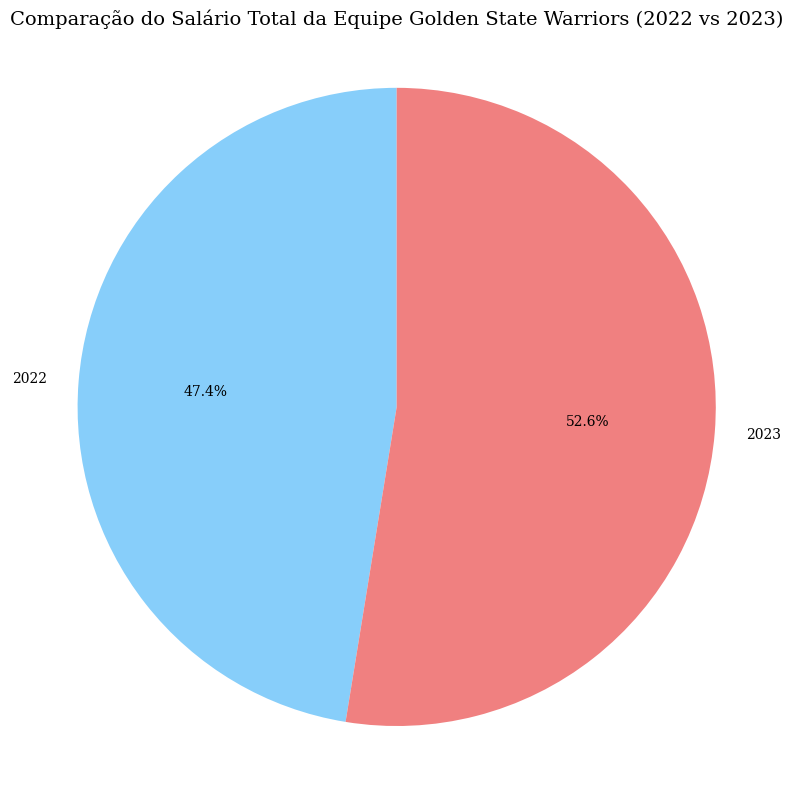

In [ ]:
# Calcular a soma dos salários para cada temporada
soma_salarios_2022 = dfGS_analise[dfGS_analise['temporada'] == 2022]['salario_usd'].sum()
soma_salarios_2023 = dfGS_analise[dfGS_analise['temporada'] == 2023]['salario_usd'].sum()

# Criar um DataFrame para o gráfico de pizza
df_total_salarios = pd.DataFrame({
    'Temporada': ['2022', '2023'],
    'Salário Total (USD)': [soma_salarios_2022, soma_salarios_2023]
})

# Plotar o gráfico de pizza
plt.figure(figsize=(8, 8))
plt.pie(df_total_salarios['Salário Total (USD)'],
        labels=df_total_salarios['Temporada'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['lightskyblue', 'lightcoral'])
plt.title('Comparação do Salário Total da Equipe Golden State Warriors (2022 vs 2023)')
plt.axis('equal') # Garante que o gráfico de pizza seja um círculo.
plt.tight_layout()
plt.show()


In [ ]:
#OS 10 MAIORES SALARIOS DO TIME E TEMPORADAS

dfGS_analise.sort_values(by='salario_usd', ascending=False).head(10)[['nome_jogador', 'temporada', 'salario_usd']]

,nome_jogador,temporada,salario_usd
4794,Stephen Curry,2023,51915615.0
4793,Stephen Curry,2022,48070014.0
5484,Klay Thompson,2023,43219440.0
5483,Klay Thompson,2022,40600080.0
6334,Andrew Wiggins,2022,33616770.0
7697,Jordan Poole,2023,27955357.0
5873,Draymond Green,2023,27586224.0
5872,Draymond Green,2022,25806468.0
6335,Andrew Wiggins,2023,24330357.0
7043,Gary Payton II,2023,8715000.0


In [ ]:
#ANALISE SALARIOS

dfGS_analise.sort_values(by='salario_usd', ascending=False).head(22)[['nome_jogador', 'salario_usd']].describe()

,salario_usd
count,2.200000e+01
mean,1.754447e+07
std,1.700353e+07
min,1.719864e+06
25%,3.905669e+06
50%,8.150000e+06
75%,2.786307e+07
max,5.191562e+07


In [ ]:
#10 maiores pontuadores
dfGS_analise.sort_values(by='pontos', ascending=False).head(10)[['nome_jogador', 'pontos', 'salario_usd' , 'temporada']]

,nome_jogador,pontos,salario_usd,temporada
7697,Jordan Poole,1675.0,27955357.0,2023
4794,Stephen Curry,1648.0,51915615.0,2023
4793,Stephen Curry,1630.0,48070014.0,2022
5484,Klay Thompson,1509.0,43219440.0,2023
7696,Jordan Poole,1405.0,3901399.0,2022
6334,Andrew Wiggins,1256.0,33616770.0,2022
8061,Jonathan Kuminga,666.0,6012840.0,2023
8060,Jonathan Kuminga,652.0,5739860.0,2022
5483,Klay Thompson,652.0,40600080.0,2022
6335,Andrew Wiggins,633.0,24330357.0,2023


In [ ]:
#ANALISE PONTUAÇÃO
dfGS_analise.sort_values(by='pontos', ascending=False).head(22)[['pontos']].describe()

,pontos
count,22.000000
mean,718.318182
std,541.325656
min,23.000000
25%,313.000000
50%,597.500000
75%,1108.500000
max,1675.000000


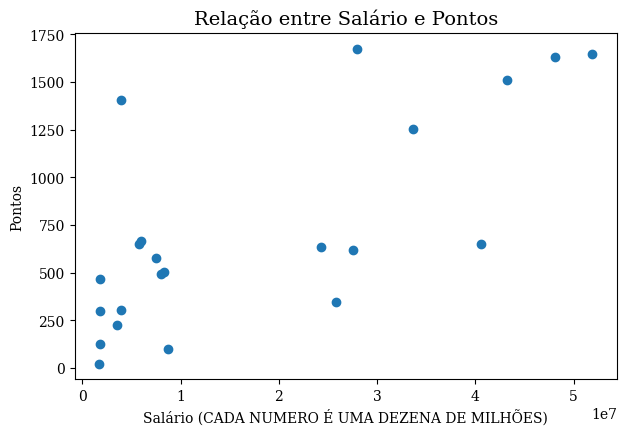

In [ ]:
#GRAFICO DE DISPERSÃO SALARIO VS PONTOS
plt.scatter(dfGS_analise['salario_usd'], dfGS_analise['pontos'])
plt.xlabel('Salário (CADA NUMERO É UMA DEZENA DE MILHÕES)')
plt.ylabel('Pontos')
plt.title('Relação entre Salário e Pontos')
plt.show()

In [ ]:
#10 maiores assistentes
dfGS_analise.sort_values(by='assistencias', ascending=False).head(10)[['nome_jogador', 'assistencias', 'salario_usd' , 'temporada']]

,nome_jogador,assistencias,salario_usd,temporada
5873,Draymond Green,500.0,27586224.0,2023
4793,Stephen Curry,404.0,48070014.0,2022
7697,Jordan Poole,369.0,27955357.0,2023
4794,Stephen Curry,352.0,51915615.0,2023
5872,Draymond Green,320.0,25806468.0,2022
7696,Jordan Poole,304.0,3901399.0,2022
6896,Kevon Looney,207.0,7500000.0,2023
6895,Kevon Looney,165.0,8000000.0,2022
5484,Klay Thompson,163.0,43219440.0,2023
6334,Andrew Wiggins,161.0,33616770.0,2022


In [ ]:
#ANALISE ASSISTENCIAS
dfGS_analise.sort_values(by='assistencias', ascending=False).head(22)[['assistencias']].describe()

,assistencias
count,22.000000
mean,172.045455
std,140.647305
min,6.000000
25%,64.000000
50%,126.000000
75%,279.750000
max,500.000000


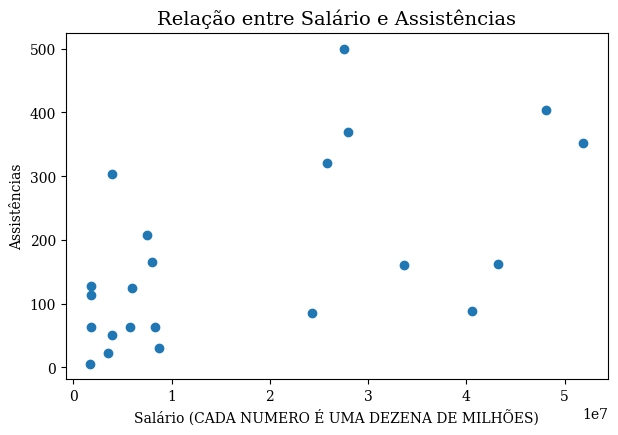

In [ ]:
#SALARIO VS ASSISTENCIA

plt.scatter(dfGS_analise['salario_usd'], dfGS_analise['assistencias'])
plt.xlabel('Salário (CADA NUMERO É UMA DEZENA DE MILHÕES)')
plt.ylabel('Assistências')
plt.title('Relação entre Salário e Assistências')
plt.show()

In [ ]:
#10 jogadores com meais rebotes
dfGS_analise.sort_values(by='rebotes', ascending=False).head(10)[['nome_jogador', 'rebotes', 'salario_usd' , 'temporada']]

,nome_jogador,rebotes,salario_usd,temporada
6896,Kevon Looney,760.0,7500000.0,2023
6895,Kevon Looney,596.0,8000000.0,2022
5873,Draymond Green,525.0,27586224.0,2023
4794,Stephen Curry,341.0,51915615.0,2023
5872,Draymond Green,336.0,25806468.0,2022
4793,Stephen Curry,335.0,48070014.0,2022
6334,Andrew Wiggins,325.0,33616770.0,2022
5484,Klay Thompson,286.0,43219440.0,2023
7696,Jordan Poole,260.0,3901399.0,2022
7042,Gary Payton II,247.0,8300000.0,2022


In [ ]:
#10 jogadores com meais rebotes
dfGS_analise.sort_values(by='rebotes', ascending=False).head(22)[['rebotes']].describe()

,rebotes
count,22.000000
mean,261.681818
std,178.998374
min,12.000000
25%,137.750000
50%,232.500000
75%,332.500000
max,760.000000


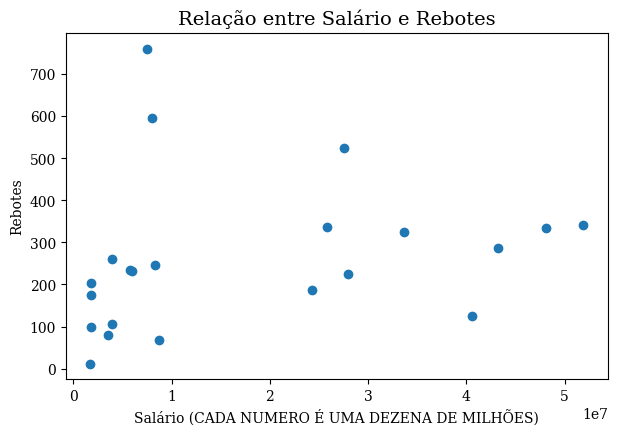

In [ ]:
#SALARIO VS REBOTES
plt.scatter(dfGS_analise['salario_usd'], dfGS_analise['rebotes'])
plt.xlabel('Salário (CADA NUMERO É UMA DEZENA DE MILHÕES)')
plt.ylabel('Rebotes')
plt.title('Relação entre Salário e Rebotes')
plt.show()

In [ ]:
#10 jogadores com mais minutos
dfGS_analise.sort_values(by='minutos_totais', ascending=False).head(22)[['minutos_totais']].describe()

,minutos_totais
count,22.000000
mean,1431.136364
std,712.719359
min,62.000000
25%,954.250000
50%,1293.000000
75%,2147.750000
max,2458.000000


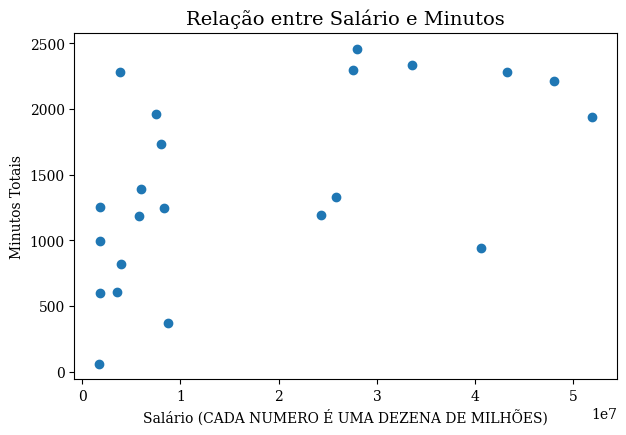

In [ ]:
plt.scatter(dfGS_analise['salario_usd'], dfGS_analise['minutos_totais'])
plt.xlabel('Salário (CADA NUMERO É UMA DEZENA DE MILHÕES)')
plt.ylabel('Minutos Totais')
plt.title('Relação entre Salário e Minutos')
plt.show()

In [ ]:
#CUSTO POR PONTO

dfGS_analise['custo_por_ponto'] = dfGS_analise['salario_usd'] / dfGS_analise['pontos']

# remover casos com pontos = 0
df_custo = dfGS_analise[dfGS_analise['pontos'] > 0]

df_custo[['nome_jogador', 'temporada', 'salario_usd', 'pontos', 'custo_por_ponto']].head()

/tmp/ipykernel_439/3014843933.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfGS_analise['custo_por_ponto'] = dfGS_analise['salario_usd'] / dfGS_analise['pontos']


,nome_jogador,temporada,salario_usd,pontos,custo_por_ponto
2974,Andre Iguodala,2022,1836090.0,124.0,14807.177419
4793,Stephen Curry,2022,48070014.0,1630.0,29490.806135
4794,Stephen Curry,2023,51915615.0,1648.0,31502.193568
5483,Klay Thompson,2022,40600080.0,652.0,62270.061350
5484,Klay Thompson,2023,43219440.0,1509.0,28641.113320


In [ ]:
#PIOR CUSTO BENEFICIO (MAIOR CUSTO POR PONTO)

df_custo.sort_values(by='custo_por_ponto', ascending=False)[['nome_jogador', 'temporada', 'salario_usd', 'pontos', 'custo_por_ponto']].head(10)

,nome_jogador,temporada,salario_usd,pontos,custo_por_ponto
7043,Gary Payton II,2023,8715000.0,101.0,86287.128713
8160,Ryan Rollins,2023,1719864.0,23.0,74776.695652
5872,Draymond Green,2022,25806468.0,346.0,74585.167630
5483,Klay Thompson,2022,40600080.0,652.0,62270.061350
5873,Draymond Green,2023,27586224.0,617.0,44710.249595
6335,Andrew Wiggins,2023,24330357.0,633.0,38436.582938
4794,Stephen Curry,2023,51915615.0,1648.0,31502.193568
4793,Stephen Curry,2022,48070014.0,1630.0,29490.806135
5484,Klay Thompson,2023,43219440.0,1509.0,28641.113320
6334,Andrew Wiggins,2022,33616770.0,1256.0,26764.944268


In [ ]:
#MELHOR CUSTO BENEFICIO (MAIS BARATO POR PONTO)

df_custo.sort_values(by='custo_por_ponto', ascending=True) [['nome_jogador', 'temporada', 'salario_usd', 'pontos', 'custo_por_ponto']].head(10)

,nome_jogador,temporada,salario_usd,pontos,custo_por_ponto
7696,Jordan Poole,2022,3901399.0,1405.0,2776.796441
7232,Damion Lee,2022,1836090.0,467.0,3931.670236
7882,Juan Toscano-Anderson,2022,1836090.0,298.0,6161.375839
8060,Jonathan Kuminga,2022,5739860.0,652.0,8803.466258
8061,Jonathan Kuminga,2023,6012840.0,666.0,9028.288288
8074,Moses Moody,2023,3918480.0,302.0,12975.099338
6896,Kevon Looney,2023,7500000.0,578.0,12975.778547
2974,Andre Iguodala,2022,1836090.0,124.0,14807.177419
8073,Moses Moody,2022,3562200.0,228.0,15623.684211
6895,Kevon Looney,2022,8000000.0,491.0,16293.279022


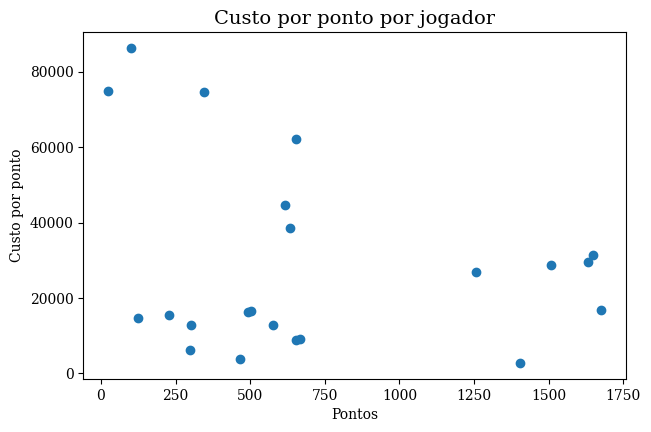

In [ ]:
#GRAFICO DE CUSTO POR PONTO

plt.scatter(df_custo['pontos'], df_custo['custo_por_ponto'])
plt.xlabel('Pontos')
plt.ylabel('Custo por ponto')
plt.title('Custo por ponto por jogador')
plt.show()

In [ ]:
#ANALISE APROFUNDADA CUSTO POR PONTO
dfGS_analise.sort_values(by='custo_por_ponto', ascending=False).head(22)[['custo_por_ponto']].describe()

,custo_por_ponto
count,22.000000
mean,28821.144940
std,24799.962333
min,2776.796441
25%,12975.269140
50%,16611.814957
75%,36702.985596
max,86287.128713
